# Fig 2 — E2 vs E3 playhead-gap boxplot

Headline figure. Shows that naive switching's playhead gap scales
with filterDelay while aligned switching is bounded by 1 GOP.

In [1]:
import sys
from pathlib import Path

# Notebook lives at paper/notebooks/, modules at paper/figures/.
sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import pandas as pd

from _data import load_aggregate
from _style import (
    COL_ALIGNED,
    COL_NAIVE,
    GOP_DURATION_MS,
    apply_acm_style,
    fig_one_col,
)

apply_acm_style()

In [2]:
e2 = load_aggregate("e2").assign(mode="naive")
e3 = load_aggregate("e3").assign(mode="aligned")
combined = pd.concat([e2, e3], ignore_index=True)

# Cell-ids are "naive_offset5", "aligned_offset5" etc. Strip the prefix
# to get the offset as an integer for x-axis sorting.
combined["offset_s"] = combined["cell_id"].str.extract(r"offset(\d+)").astype(int)
combined = combined.sort_values(["offset_s", "mode"])

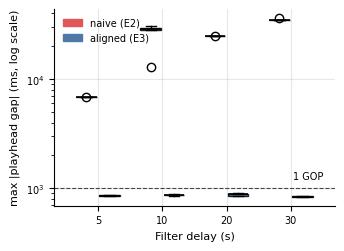

In [3]:
fig, ax = fig_one_col(height_in=2.4)

offsets = sorted(combined["offset_s"].unique())
positions_naive = [i - 0.18 for i in range(len(offsets))]
positions_aligned = [i + 0.18 for i in range(len(offsets))]

naive_data = [combined.query("mode == 'naive' and offset_s == @o")["max_playhead_gap_ms"].values for o in offsets]
aligned_data = [combined.query("mode == 'aligned' and offset_s == @o")["max_playhead_gap_ms"].values for o in offsets]

bp_n = ax.boxplot(naive_data, positions=positions_naive, widths=0.32, patch_artist=True,
                  medianprops={"color": "black", "linewidth": 1.2})
bp_a = ax.boxplot(aligned_data, positions=positions_aligned, widths=0.32, patch_artist=True,
                  medianprops={"color": "black", "linewidth": 1.2})
for patch in bp_n["boxes"]:
    patch.set_facecolor(COL_NAIVE)
    patch.set_alpha(0.85)
for patch in bp_a["boxes"]:
    patch.set_facecolor(COL_ALIGNED)
    patch.set_alpha(0.85)

ax.set_yscale("log")
ax.set_xticks(range(len(offsets)))
ax.set_xticklabels([f"{o}" for o in offsets])
ax.set_xlabel("Filter delay (s)")
ax.set_ylabel("max |playhead gap| (ms, log scale)")

# 1-GOP reference line.
ax.axhline(GOP_DURATION_MS, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.text(len(offsets) - 0.5, GOP_DURATION_MS * 1.15, "1 GOP",
        fontsize=7, ha="right", va="bottom")

# Legend via proxy artists.
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color=COL_NAIVE, label="naive (E2)"),
    mpatches.Patch(color=COL_ALIGNED, label="aligned (E3)"),
], loc="upper left", frameon=False)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig2_e2_e3_playhead_gap.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig2_e2_e3_playhead_gap.png", dpi=200)  # for quick visual review